# Box, violin, and ridge plots

Grouped distribution comparison with box, violin, ridge, and jitter plots.

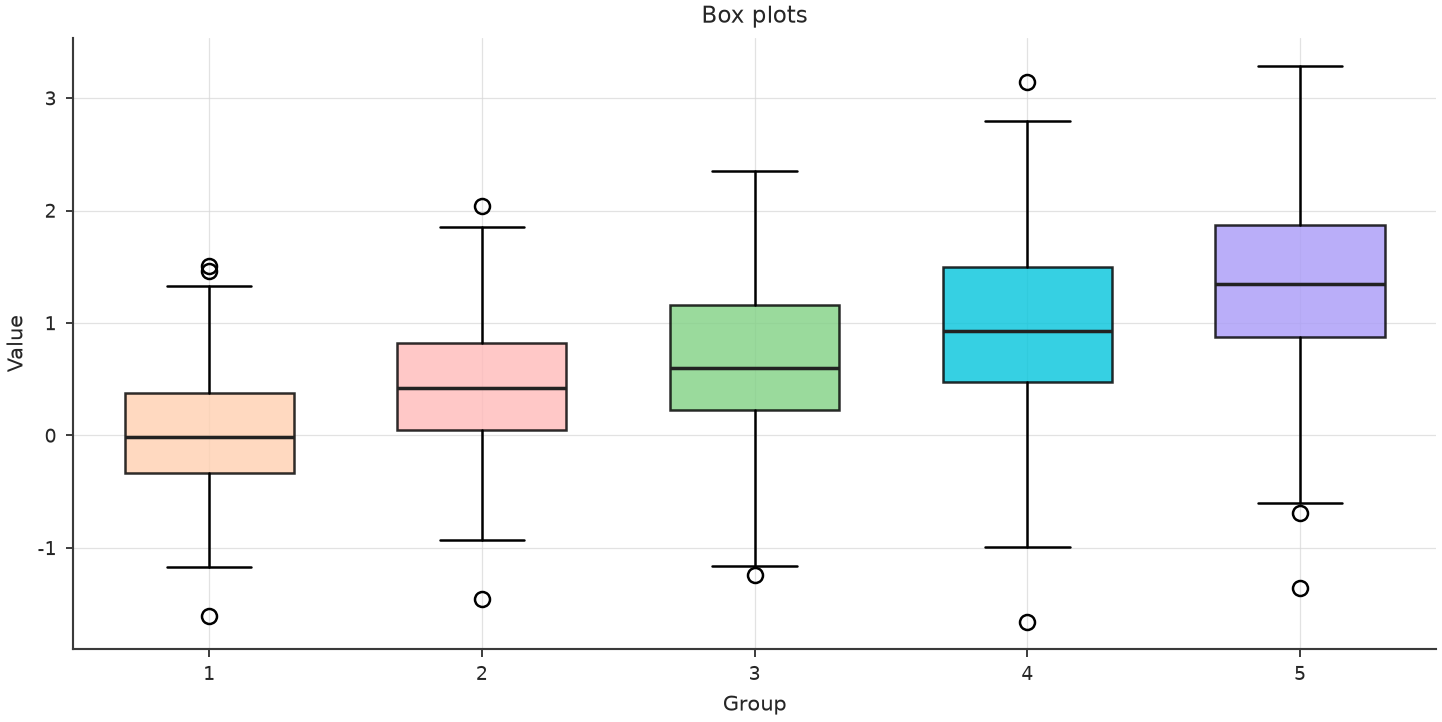

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import contrastcolors as cc

cc.set_style("heri", font="DejaVu Sans")
rng=np.random.default_rng(14)
groups=[rng.normal(i*0.35,0.55+0.08*i,220) for i in range(5)]
colors=cc.color_palette(hues=[55,20,145,210,290],ratio=1.14,start_luminance=0.70)

fig,ax=plt.subplots(figsize=(8.2,4.2))
bp=ax.boxplot(groups,patch_artist=True,widths=0.62)
for patch,color in zip(bp["boxes"],colors):
    patch.set_facecolor(color); patch.set_alpha(0.82)
for median in bp["medians"]:
    median.set_color("#222222"); median.set_linewidth(1.4)
ax.set(title="Box plots",xlabel="Group",ylabel="Value")
fig.tight_layout()

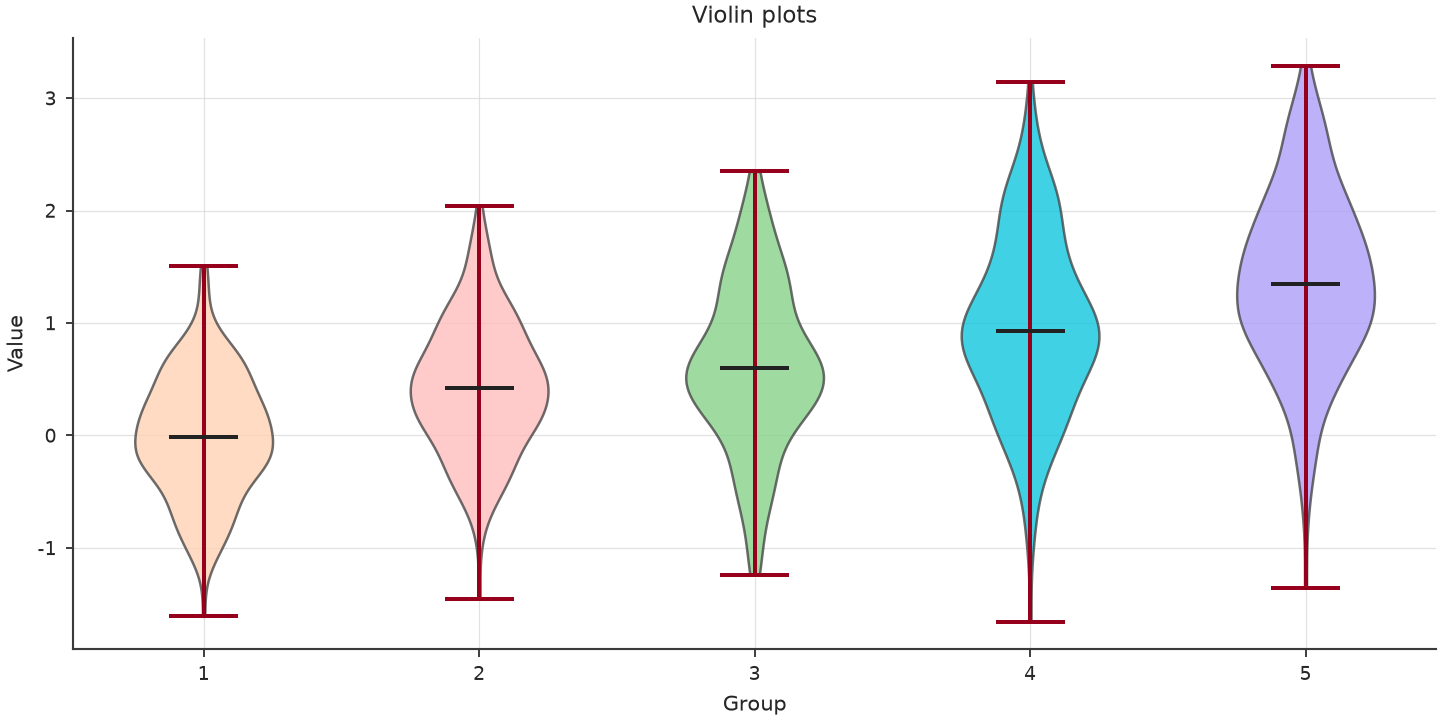

In [2]:
fig,ax=plt.subplots(figsize=(8.2,4.2))
vp=ax.violinplot(groups,showmeans=False,showmedians=True)
for body,color in zip(vp["bodies"],colors):
    body.set_facecolor(color); body.set_edgecolor("#444444"); body.set_alpha(0.78)
vp["cmedians"].set_color("#222222")
ax.set(title="Violin plots",xlabel="Group",ylabel="Value")
fig.tight_layout()

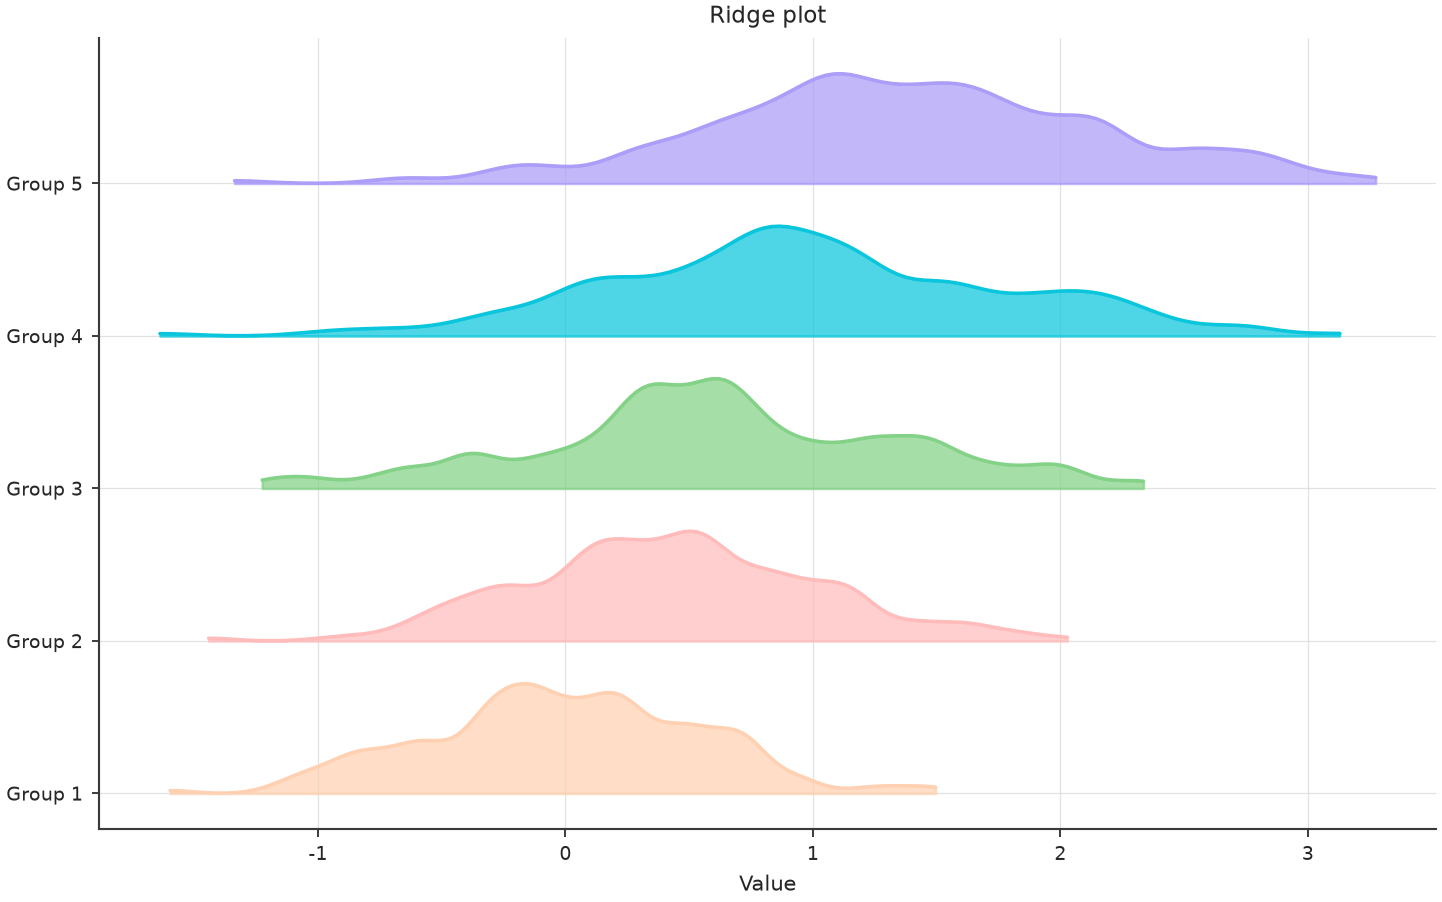

In [3]:
def ridge_density(values,bins=140,sigma_bins=4):
    counts,edges=np.histogram(values,bins=bins,density=True)
    centers=0.5*(edges[:-1]+edges[1:])
    radius=int(4*sigma_bins)
    kx=np.arange(-radius,radius+1)
    kernel=np.exp(-0.5*(kx/sigma_bins)**2); kernel/=kernel.sum()
    return centers,np.convolve(counts,kernel,mode="same")

fig,ax=plt.subplots(figsize=(8.2,5.2))
for i,(values,color) in enumerate(zip(groups,colors)):
    xx,yy=ridge_density(values)
    yy=yy/yy.max()*0.72
    ax.fill_between(xx,i,i+yy,color=color,alpha=0.72)
    ax.plot(xx,i+yy,color=color,linewidth=1.4)
ax.set_yticks(range(len(groups)),[f"Group {i+1}" for i in range(len(groups))])
ax.set(title="Ridge plot",xlabel="Value",ylabel="")
fig.tight_layout()

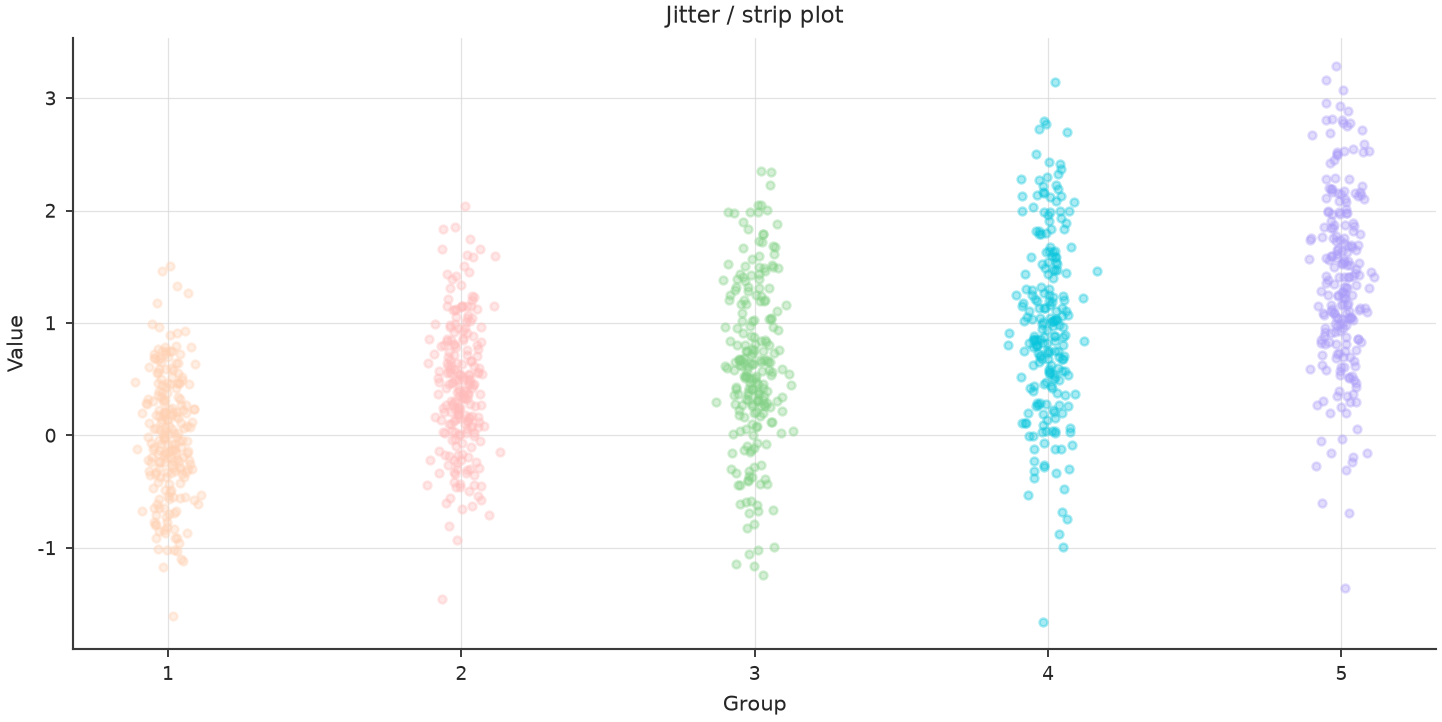

In [4]:
fig,ax=plt.subplots(figsize=(8.2,4.2))
for i,(values,color) in enumerate(zip(groups,colors),start=1):
    jitter=rng.normal(0,0.045,len(values))
    ax.scatter(np.full_like(values,i,dtype=float)+jitter,values,s=10,alpha=0.35,color=color)
ax.set(title="Jitter / strip plot",xlabel="Group",ylabel="Value")
fig.tight_layout()